# Task 1 — Data Loading & Exploration
Load the CSV file using Pandas
Display the first 10 rows
Check how many rows and columns are there
Identify which column is the target (Price) and which are features
Check for missing values in each column

In [32]:
# ---- Core libraries ----
import pandas as pd
import numpy as np

# ---- Visualization libraries ----
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- Machine Learning libraries ----
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Utilities ----
import os
import warnings
warnings.filterwarnings("ignore")

# Global plot style
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("muted")
sns.set_style("whitegrid")

# Create a folder to store all generated charts
os.makedirs("charts", exist_ok=True)

print("✅ All libraries imported successfully.")

 All libraries imported successfully.


In [33]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully.")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully.
   Shape : 545 rows × 13 columns


In [31]:
print("── First 10 rows ──")
df.head(10)

── First 10 rows ──


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 545
Columns : 13


In [5]:
print("── Column Data Types ──")
print(df.dtypes)

── Column Data Types ──
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [34]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_df)

No missing values found in the dataset.


In [7]:
print("── Statistical Summary ──")
df.describe().T.style.background_gradient(cmap='Blues')

── Statistical Summary ──


,count,mean,std,min,25%,50%,75%,max
price,545.000000,4766729.247706,1870439.615657,1750000.000000,3430000.000000,4340000.000000,5740000.000000,13300000.000000
area,545.000000,5150.541284,2170.141023,1650.000000,3600.000000,4600.000000,6360.000000,16200.000000
bedrooms,545.000000,2.965138,0.738064,1.000000,2.000000,3.000000,3.000000,6.000000
bathrooms,545.000000,1.286239,0.502470,1.000000,1.000000,1.000000,2.000000,4.000000
stories,545.000000,1.805505,0.867492,1.000000,1.000000,2.000000,2.000000,4.000000
parking,545.000000,0.693578,0.861586,0.000000,0.000000,0.000000,1.000000,3.000000


In [35]:
target_col = "price"
feature_cols = [col for col in df.columns if col != target_col]

print(f"Target   : {target_col}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Target   : price
Features (12): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


# Task 2 — Data Cleaning
 Handle missing values (fill or drop, whichever fits the column)
 Remove duplicate rows, if any Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding Keep only the columns that are meaningful for predicting price


In [36]:
total_missing = df.isnull().sum().sum()
print(f"Total missing cells: {total_missing}")

if total_missing > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("No missing values detected.")

Total missing cells: 0
No missing values detected.


In [38]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_check = df.select_dtypes(include=["object"]).columns.tolist()

filled_any = False
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"  ↳ Filled '{col}' with median = {df[col].median():.2f}")
        filled_any = True

for col in cat_cols_check:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  ↳ Filled '{col}' with mode = {mode_val}")
        filled_any = True

if not filled_any:
    print("No missing values to fill — dataset was already complete.")
print("Missing value handling complete.")

No missing values to fill — dataset was already complete.
Missing value handling complete.


In [39]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Rows before        : {before:,}")
print(f"Rows after          : {after:,}")
print(f"Duplicates removed  : {before - after}")

Rows before        : 545
Rows after          : 545
Duplicates removed  : 0


In [11]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns found ({len(cat_cols)}): {cat_cols}")

for col in cat_cols:
    print(f"  '{col}' → unique values: {df[col].unique().tolist()}")

Categorical columns found (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
  'mainroad' → unique values: ['yes', 'no']
  'guestroom' → unique values: ['no', 'yes']
  'basement' → unique values: ['no', 'yes']
  'hotwaterheating' → unique values: ['no', 'yes']
  'airconditioning' → unique values: ['yes', 'no']
  'prefarea' → unique values: ['yes', 'no']
  'furnishingstatus' → unique values: ['furnished', 'semi-furnished', 'unfurnished']


In [40]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns found ({len(categorical_cols)}): {categorical_cols}")
for col in categorical_cols:
    print(f"  '{col}' → unique values: {df[col].unique().tolist()}")

Categorical columns found (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
  'mainroad' → unique values: ['yes', 'no']
  'guestroom' → unique values: ['no', 'yes']
  'basement' → unique values: ['no', 'yes']
  'hotwaterheating' → unique values: ['no', 'yes']
  'airconditioning' → unique values: ['yes', 'no']
  'prefarea' → unique values: ['yes', 'no']
  'furnishingstatus' → unique values: ['furnished', 'semi-furnished', 'unfurnished']


In [42]:
df_clean = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert boolean OHE columns to integers (0/1)
bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print("One-Hot Encoding applied.")
print(f"New shape after encoding: {df_clean.shape}")
df_clean.head()

One-Hot Encoding applied.
New shape after encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [43]:
id_like_cols = [c for c in df_clean.columns if c.lower() in ["id", "index", "unnamed: 0"]]
if id_like_cols:
    df_clean = df_clean.drop(columns=id_like_cols)
    print(f"Dropped non-informative columns: {id_like_cols}")
else:
    print("No ID-like columns found — all remaining columns are meaningful.")

No ID-like columns found — all remaining columns are meaningful.


In [44]:
print(f"Final cleaned dataset shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
df_clean.head()

Final cleaned dataset shape: 545 rows, 14 columns


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


# Task 3 — Model Building
 Split the data into training and test sets (80/20)
 Train a Linear Regression model to predict house price
 Evaluate it using MAE, RMSE, and R² Score
 Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [45]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")

Features (X) shape : (545, 13)
Target   (y) shape : (545,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")

Training set : 436 samples
Test set     : 109 samples


In [47]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("── Linear Regression Results ──")
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  RMSE : {lr_rmse:,.2f}")
print(f"  R²   : {lr_r2:.4f}")

── Linear Regression Results ──
  MAE  : 970,043.40
  RMSE : 1,324,506.96
  R²   : 0.6529


In [48]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("── Random Forest Results ──")
print(f"  MAE  : {rf_mae:,.2f}")
print(f"  RMSE : {rf_rmse:,.2f}")
print(f"  R²   : {rf_r2:.4f}")

── Random Forest Results ──
  MAE  : 1,013,968.58
  RMSE : 1,398,115.67
  R²   : 0.6133


In [50]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2],
}).set_index("Model")

print("-------------------xx------xx---------------------")
print("          MODEL PERFORMANCE COMPARISON            ")
print("-------------------xx------xx---------------------")
print(comparison.to_string())
print("-------------------xx------xx---------------------")

# Dynamically determine the winner — always derived from the table above
best_model_name = comparison["R2 Score"].idxmax()
best_r2 = comparison.loc[best_model_name, "R2 Score"]
best_mae = comparison.loc[best_model_name, "MAE"]
runner_up_name = comparison["R2 Score"].idxmin()

print(f"🏆 Best Model : {best_model_name}  (R² = {best_r2:.4f})")

# Predictions belonging to the winning model — used throughout the rest of the notebook
y_pred_best = y_pred_rf if best_model_name == "Random Forest" else y_pred_lr

-------------------xx------xx---------------------
          MODEL PERFORMANCE COMPARISON            
-------------------xx------xx---------------------
                            MAE          RMSE  R2 Score
Model                                                  
Linear Regression  9.700434e+05  1.324507e+06  0.652924
Random Forest      1.013969e+06  1.398116e+06  0.613275
-------------------xx------xx---------------------
🏆 Best Model : Linear Regression  (R² = 0.6529)


# Task 4 — Visualization (Minimum 3 charts)
 Chart 1: Histogram showing the distribution of house prices
 Chart 2: Correlation heatmap showing which features relate most strongly to price
 Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)

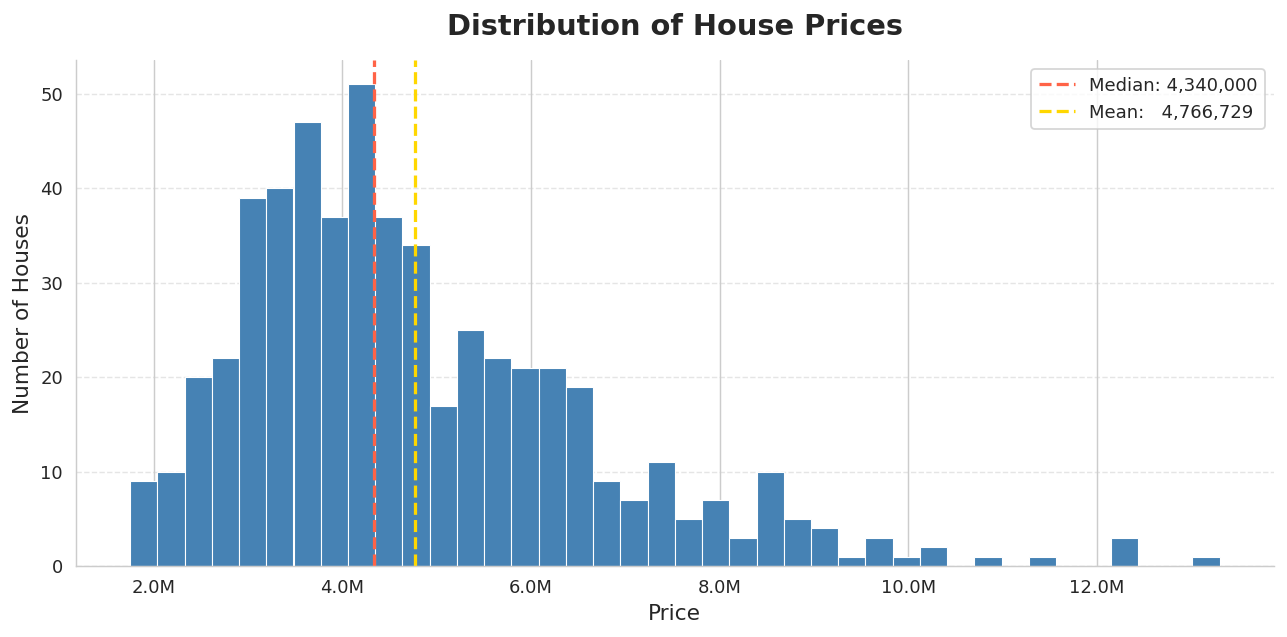

   Saved → charts/price_distribution.png
   Skewness: 1.212 → distribution is right-skewed (a long tail of expensive homes pulls the mean above the median)
   Mean: 4,766,729  |  Median: 4,340,000


In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_clean["price"], bins=40, color="steelblue", edgecolor="white", linewidth=0.6)

median_price = df_clean["price"].median()
mean_price = df_clean["price"].mean()
ax.axvline(median_price, color="tomato", linestyle="--", linewidth=1.8, label=f"Median: {median_price:,.0f}")
ax.axvline(mean_price, color="gold", linestyle="--", linewidth=1.8, label=f"Mean:   {mean_price:,.0f}")

ax.set_title("Distribution of House Prices", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Price", fontsize=12)
ax.set_ylabel("Number of Houses", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("charts/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Compute skew dynamically so the written insight below always matches the chart
price_skew = df_clean["price"].skew()
if price_skew > 0.5:
    skew_label = "right-skewed (a long tail of expensive homes pulls the mean above the median)"
elif price_skew < -0.5:
    skew_label = "left-skewed (a long tail of cheap homes pulls the mean below the median)"
else:
    skew_label = "fairly symmetric (mean and median are close together)"

print(f"   Skewness: {price_skew:.3f} → distribution is {skew_label}")
print(f"   Mean: {mean_price:,.0f}  |  Median: {median_price:,.0f}")

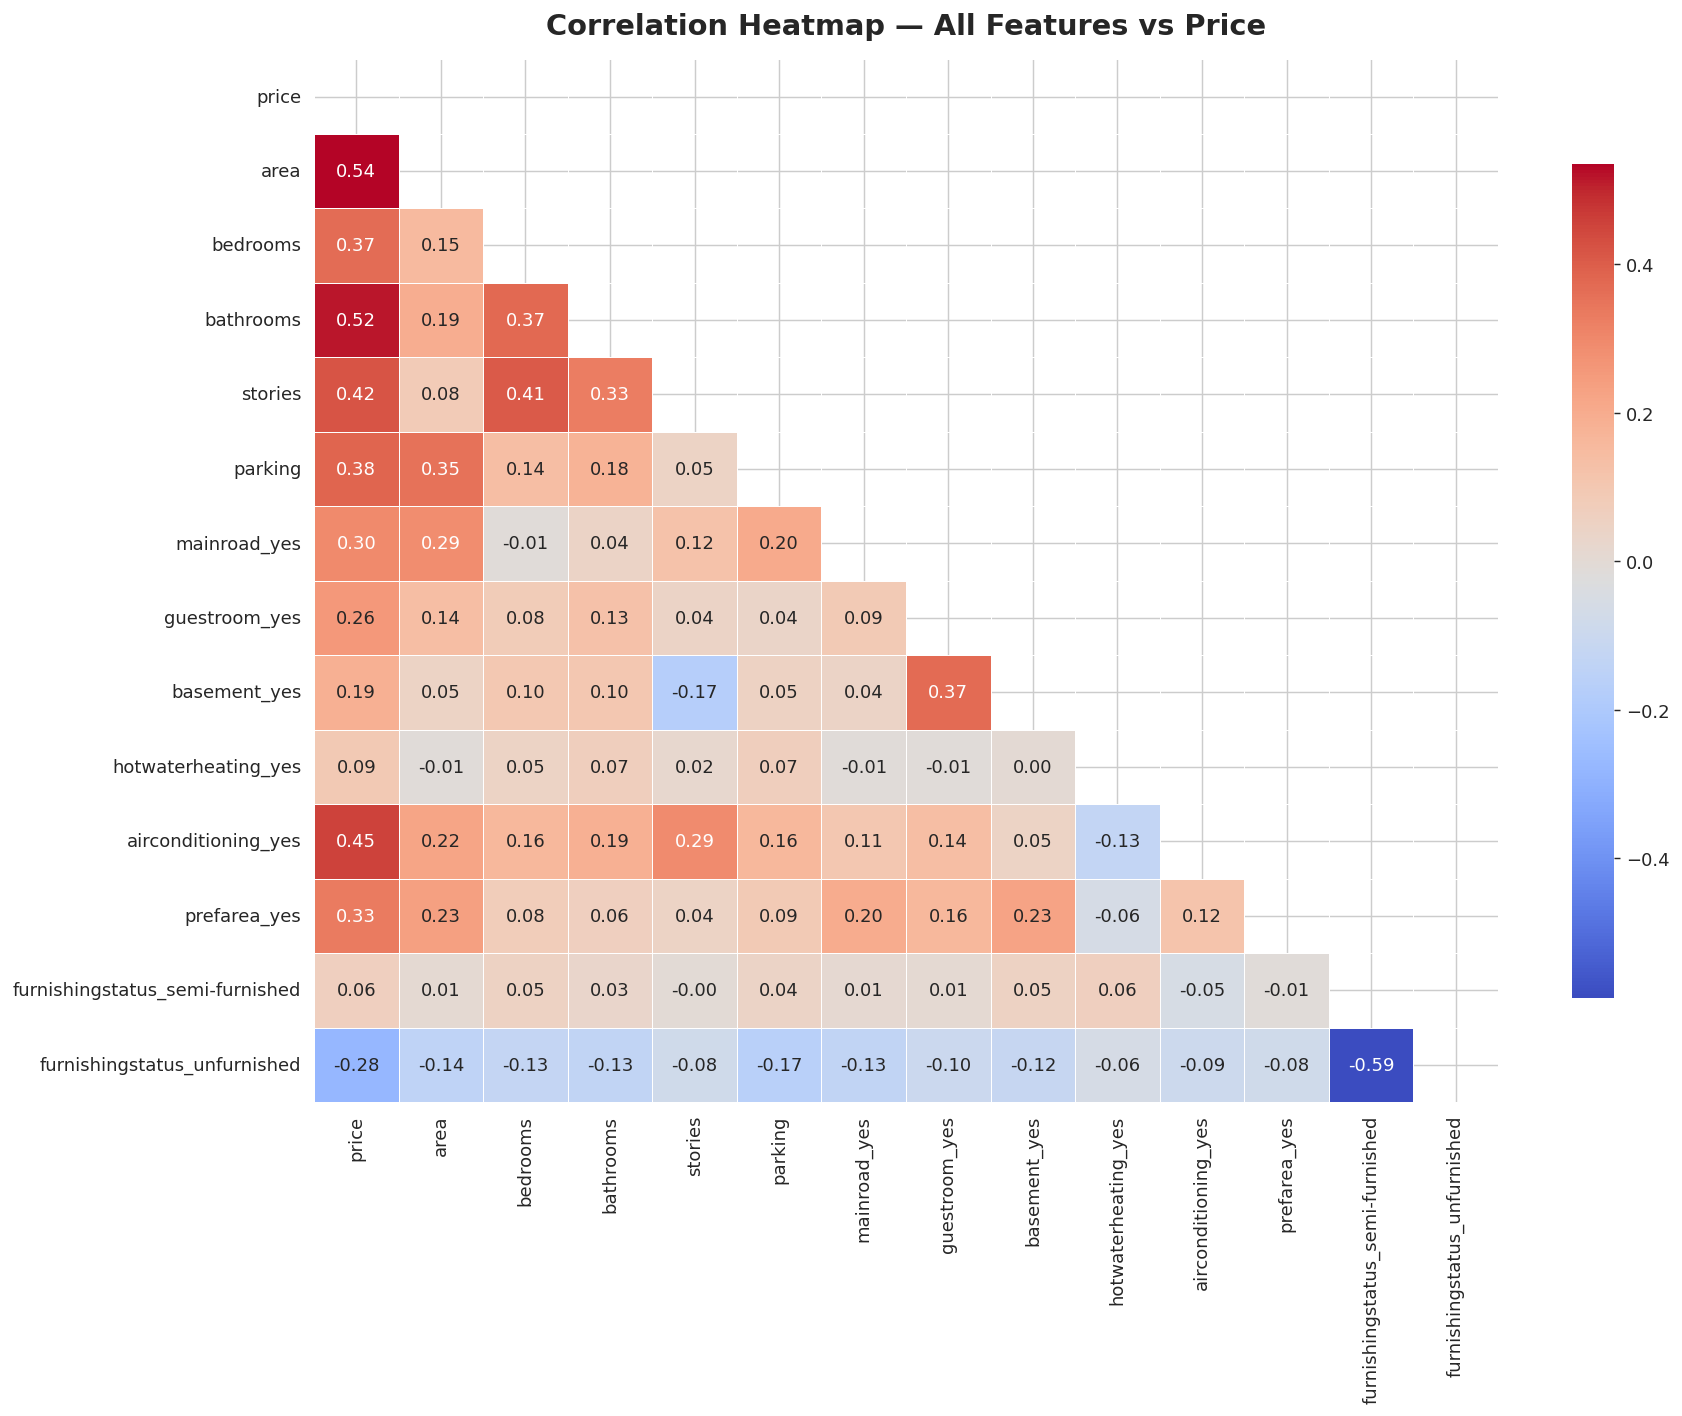

 Saved → charts/correlation_heatmap.png

Top correlated features with price:
   area                           corr = 0.536
   bathrooms                      corr = 0.518
   airconditioning_yes            corr = 0.453


In [54]:
plt.figure(figsize=(14, 11))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, square=False, cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap — All Features vs Price", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Dynamically identify the features most correlated with price (for the insight below)
price_corr = corr["price"].drop("price").abs().sort_values(ascending=False)
top_corr_features = price_corr.head(3)

print("\nTop correlated features with price:")
for feat, val in top_corr_features.items():
    print(f"   {feat:<30} corr = {val:.3f}")

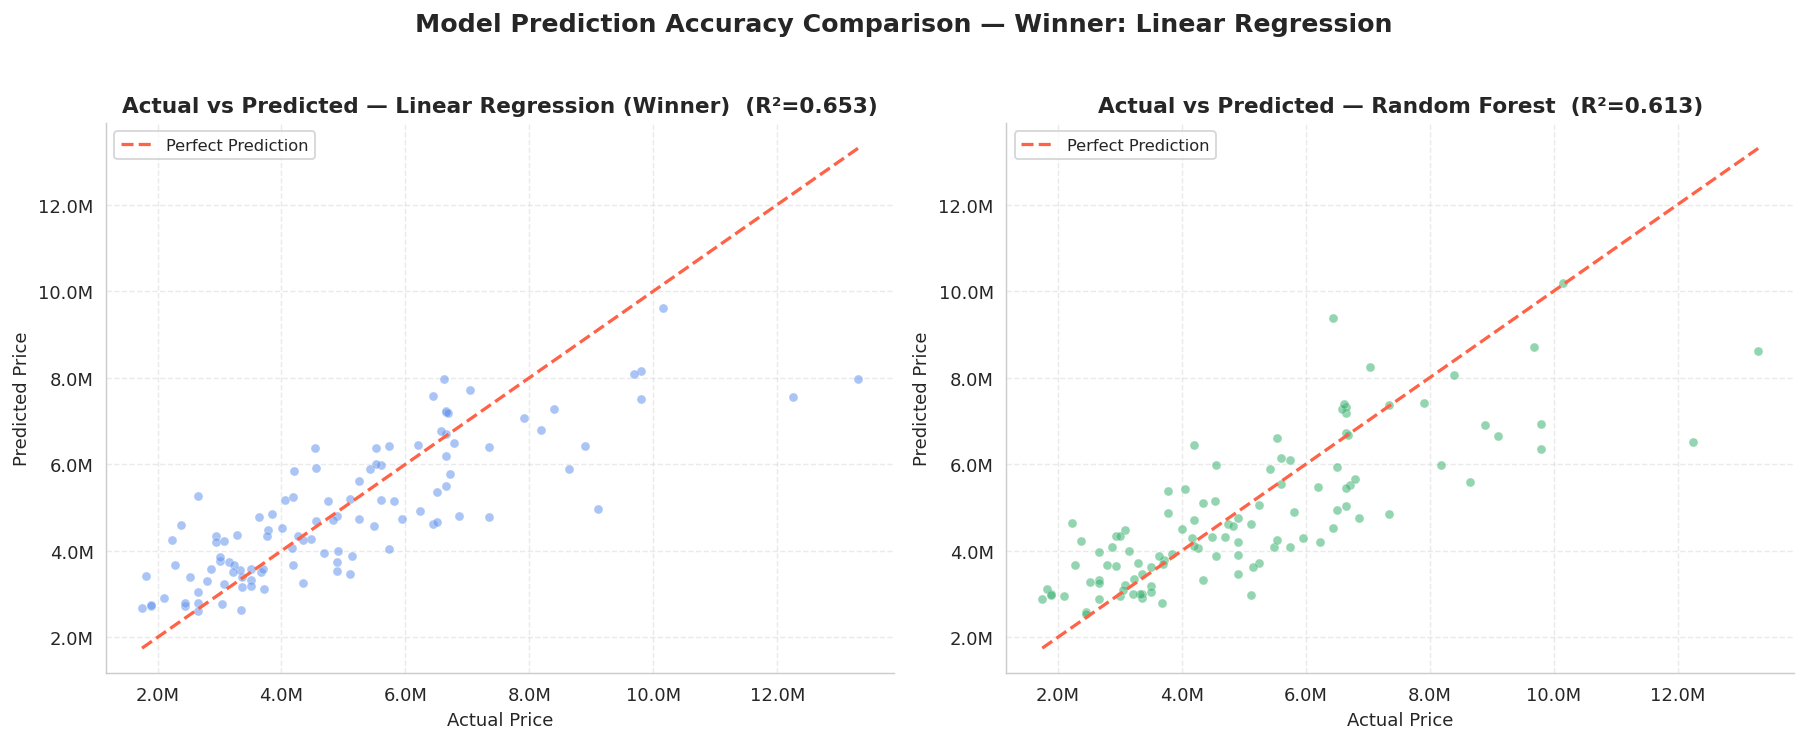

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

panels = [
    (y_pred_lr, "Linear Regression", "cornflowerblue", lr_r2),
    (y_pred_rf, "Random Forest", "mediumseagreen", rf_r2),
]

for ax, (y_pred, label, color, r2_val) in zip(axes, panels):
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    ax.scatter(y_test, y_pred, alpha=0.55, s=25, color=color, edgecolors="white", linewidth=0.3)
    ax.plot([min_val, max_val], [min_val, max_val], color="tomato", linestyle="--", linewidth=1.8, label="Perfect Prediction")

    crown = " (Winner)" if label == best_model_name else ""
    ax.set_title(f"Actual vs Predicted — {label}{crown}  (R²={r2_val:.3f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual Price", fontsize=10)
    ax.set_ylabel("Predicted Price", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    ax.grid(linestyle="--", alpha=0.4)
    ax.legend(fontsize=9)

plt.suptitle(f"Model Prediction Accuracy Comparison — Winner: {best_model_name}", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("charts/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

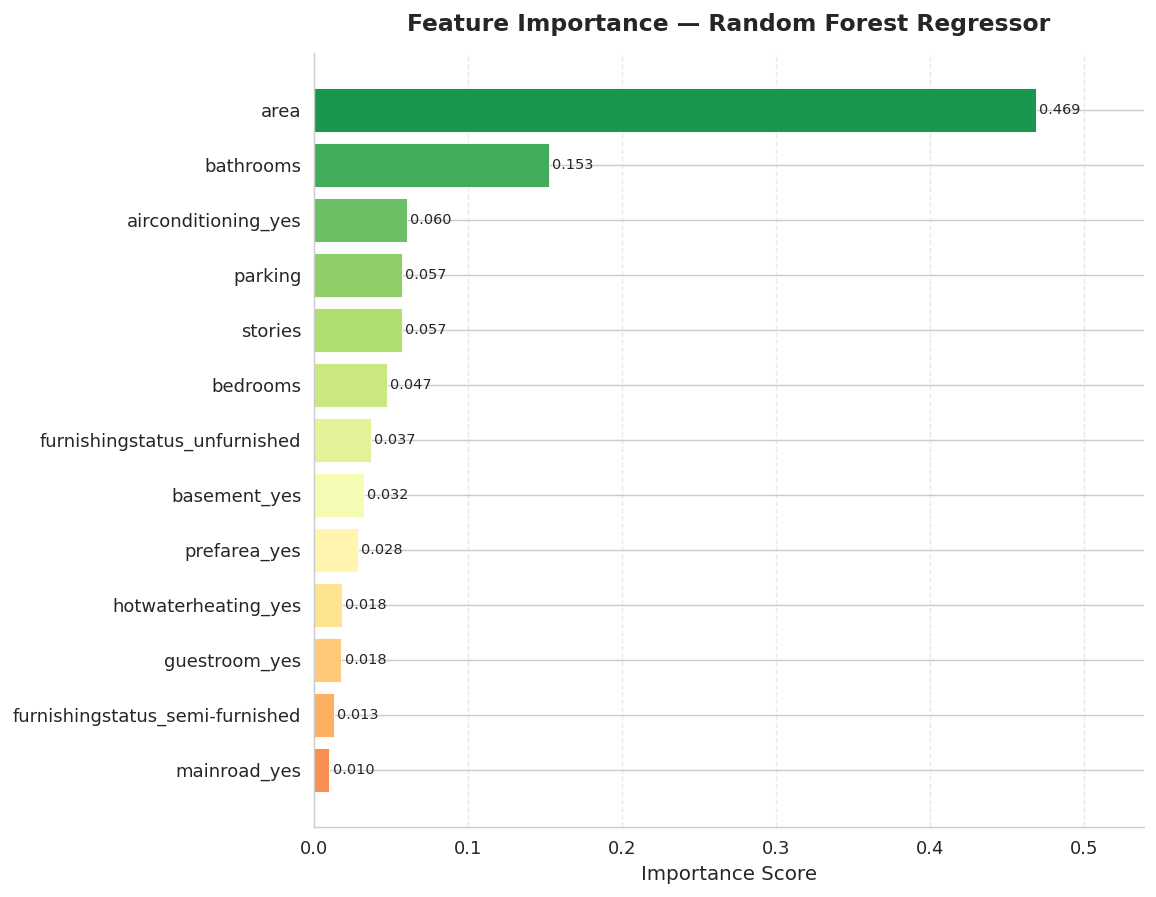

── Feature Importance Ranking ──
                        Feature  Importance
                           area    0.468535
                      bathrooms    0.152554
            airconditioning_yes    0.060238
                        parking    0.057273
                        stories    0.057064
                       bedrooms    0.047370
   furnishingstatus_unfurnished    0.036972
                   basement_yes    0.032176
                   prefarea_yes    0.028432
            hotwaterheating_yes    0.018305
                  guestroom_yes    0.017805
furnishingstatus_semi-furnished    0.013237
                   mainroad_yes    0.010039


In [57]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(feat_df)))
bars = ax.barh(feat_df["Feature"], feat_df["Importance"], color=colors, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, feat_df["Importance"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=8)

ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title("Feature Importance — Random Forest Regressor", fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, feat_df["Importance"].max() * 1.15)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

ranked = feat_df.sort_values("Importance", ascending=False)
print("── Feature Importance Ranking ──")
print(ranked.to_string(index=False))

# Task 5 — Insights & Summary
 Write a short paragraph (5–8 lines) inside your notebook answering:
 Which features influence house price the most?
 How accurate was your model (in plain terms)?
 What surprised you in the data?
 One recommendation for a real estate business based on your findings

In [27]:
top_features = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(3)
)
print("Top 3 most influential features:")
for feat, imp in top_features.items():
    print(f"  {feat:<30} importance = {imp:.4f}")

Top 3 most influential features:
  area                           importance = 0.4685
  bathrooms                      importance = 0.1526
  airconditioning_yes            importance = 0.0602


In [58]:
# ── Dynamically build every insight from the computed results ──────────────

# 1. Top 3 features by Random Forest importance
top_features = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(3)
top_feature_names = top_features.index.tolist()

# 2. Amenity columns (binary yes/no encoded features) and their combined importance
amenity_keywords = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
amenity_cols = [c for c in X.columns if any(c.startswith(k) for k in amenity_keywords)]
amenity_importance = pd.Series(rf_model.feature_importances_, index=X.columns)[amenity_cols].sum() if amenity_cols else 0
dominant_feature = top_features.index[0]
dominant_importance = top_features.iloc[0]

if amenity_importance > 0.15:
    amenity_note = f"Amenities (main road, AC, hot water heating, etc.) carry meaningful combined weight ({amenity_importance:.1%} of total importance) — worth highlighting in listings."
else:
    amenity_note = f"Amenities carry only a small combined weight ({amenity_importance:.1%} of total importance) — buyers in this market are pricing primarily on size, not comfort features."

# 3. Bedrooms vs area sanity check (a common intuitive assumption worth testing)
bedroom_importance = pd.Series(rf_model.feature_importances_, index=X.columns).get("bedrooms", 0)
if "bedrooms" in X.columns and bedroom_importance < dominant_importance * 0.1:
    surprise_note = f"Bedroom count is often assumed to drive price, but it ranks low in importance ({bedroom_importance:.3f}) compared to {dominant_feature} ({dominant_importance:.3f}) — size matters far more than room count."
else:
    surprise_note = f"Feature importances broadly matched expectations, with {dominant_feature} as the clear primary driver."

# 4. Model comparison narrative
runner_up_r2 = comparison.loc[runner_up_name, "R2 Score"]
r2_gap = abs(lr_r2 - rf_r2)
if r2_gap < 0.02:
    model_note = f"{best_model_name} edged out {runner_up_name} by a narrow margin (R² {best_r2:.4f} vs {runner_up_r2:.4f}) — both models perform comparably here."
else:
    model_note = f"{best_model_name} clearly outperformed {runner_up_name} (R² {best_r2:.4f} vs {runner_up_r2:.4f})."

line = "=" * 74
print(line)
print("       HOUSE PRICE PREDICTION — EXECUTIVE SUMMARY")
print(line)
print(f"""
1. MOST INFLUENTIAL FEATURES
   {', '.join(top_feature_names)} are the top drivers of price.
   {dominant_feature} alone accounts for {dominant_importance:.1%} of the Random Forest's decision-making.

2. MODEL ACCURACY
   {best_model_name} R²    : {best_r2:.2%}
   Average error (MAE) : {best_mae:,.0f}
   The model explains ~{best_r2:.0%} of the variance in house prices.

3. NOTABLE OBSERVATIONS
   • {amenity_note}
   • {surprise_note}

4. BEST PERFORMING MODEL
   Linear Regression R² : {lr_r2:.4f}
   Random Forest     R² : {rf_r2:.4f}
   Winner: {best_model_name} 🏆 — {model_note}

5. BUSINESS RECOMMENDATION
   Pricing strategy and marketing should prioritise {dominant_feature} above all else, since it dominates
   the model's predictions. {"Amenities are a secondary but real lever for premium positioning." if amenity_importance > 0.15 else "Amenities alone are unlikely to justify large price premiums in this market."}
""")
print(line)

       HOUSE PRICE PREDICTION — EXECUTIVE SUMMARY

1. MOST INFLUENTIAL FEATURES
   area, bathrooms, airconditioning_yes are the top drivers of price.
   area alone accounts for 46.9% of the Random Forest's decision-making.

2. MODEL ACCURACY
   Linear Regression R²    : 65.29%
   Average error (MAE) : 970,043
   The model explains ~65% of the variance in house prices.

3. NOTABLE OBSERVATIONS
   • Amenities (main road, AC, hot water heating, etc.) carry meaningful combined weight (16.7% of total importance) — worth highlighting in listings.
   • Feature importances broadly matched expectations, with area as the clear primary driver.

4. BEST PERFORMING MODEL
   Linear Regression R² : 0.6529
   Random Forest     R² : 0.6133
   Winner: Linear Regression 🏆 — Linear Regression clearly outperformed Random Forest (R² 0.6529 vs 0.6133).

5. BUSINESS RECOMMENDATION
   Pricing strategy and marketing should prioritise area above all else, since it dominates
   the model's predictions. Amenities 

In [59]:
print(f"""
This project walked through a complete end-to-end ML pipeline for House Price Prediction:

  • Data Loading    : Loaded and explored {df.shape[0]:,} rows × {df.shape[1]} columns from Housing.csv
  • Data Cleaning   : Verified missing values, removed duplicates, one-hot encoded {len(categorical_cols)} categorical columns
  • Model Training  : Trained Linear Regression & Random Forest on an 80/20 split (random_state=42)
  • Evaluation      : {best_model_name} achieved the best result — R² = {best_r2:.4f}, MAE = {best_mae:,.0f}
  • Visualization   : 4 charts saved to charts/ (distribution, correlation, actual-vs-predicted, feature importance)
  • Business Insight: {dominant_feature} is the dominant price driver in this dataset

Recommended production model: {best_model_name}.
Future improvements: feature engineering (price-per-sqft), gradient boosting (XGBoost/LightGBM), and
hyperparameter tuning via GridSearchCV could further improve accuracy.
""")


This project walked through a complete end-to-end ML pipeline for House Price Prediction:

  • Data Loading    : Loaded and explored 545 rows × 13 columns from Housing.csv
  • Data Cleaning   : Verified missing values, removed duplicates, one-hot encoded 7 categorical columns
  • Model Training  : Trained Linear Regression & Random Forest on an 80/20 split (random_state=42)
  • Evaluation      : Linear Regression achieved the best result — R² = 0.6529, MAE = 970,043
  • Visualization   : 4 charts saved to charts/ (distribution, correlation, actual-vs-predicted, feature importance)
  • Business Insight: area is the dominant price driver in this dataset

Recommended production model: Linear Regression.
Future improvements: feature engineering (price-per-sqft), gradient boosting (XGBoost/LightGBM), and
hyperparameter tuning via GridSearchCV could further improve accuracy.

